In [1]:
pip install openpyxl pandas numpy

Note: you may need to restart the kernel to use updated packages.


# Step 1: Large-Scale Data Generation

In [2]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import time

# --- CONFIGURATION ---
NUM_ROWS = 500000  # I'm setting the target to 1/2 Million Rows
OUTPUT_FILE = "integrated_traffic_dataset_100_cols.xlsx"
random.seed(42)
np.random.seed(42)

print(f" Starting the engine! I'm about to generate {NUM_ROWS} rows of synthetic traffic data with 105 attributes...")
start_time = time.time()

# --- HELPER FUNCTIONS ---
def generate_timestamps(n):
    # I'll create a range of dates from 2019 to 2024
    start_date = datetime(2019, 1, 1)
    end_date = datetime(2024, 1, 1)
    delta = end_date - start_date
    total_seconds = int(delta.total_seconds())
    # Picking random seconds to distribute accidents naturally
    random_seconds = np.random.randint(0, total_seconds, n)
    random_seconds.sort() # Sorting them so the dataset looks chronological
    return [start_date + timedelta(seconds=int(s)) for s in random_seconds]

# --- 1. CORE IDENTIFIERS (6 Cols) ---
print("Step 1/8: Creating the core identifiers (ID, Date, Location)...")
df = pd.DataFrame()
df['Accident_ID'] = [f'ACC_{i:07d}' for i in range(1, NUM_ROWS + 1)]

# I'm calling my helper function to get the timeline ready
timestamps = generate_timestamps(NUM_ROWS)

df['Date'] = [t.date() for t in timestamps]
df['Time'] = [t.time() for t in timestamps]
df['Quarter'] = [((t.month - 1) // 3) + 1 for t in timestamps]
df['Year'] = [t.year for t in timestamps]
df['Police_Station_Name'] = np.random.choice(['Central', 'Airport', 'Indiranagar', 'Koramangala', 'Whitefield', 'Hebbal', 'Jayanagar', 'Madiwala'], NUM_ROWS)
df['Reporting_Officer_ID'] = np.random.randint(1000, 9999, NUM_ROWS)

# --- 2. TEMPORAL & ENVIRONMENTAL (16 Cols) ---
print("Step 2/8: Simulating the environment (Weather, Lighting, Season)...")
df['Day_of_Week'] = [t.strftime('%A') for t in timestamps]
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)
df['Is_Holiday'] = np.random.choice([0, 1], NUM_ROWS, p=[0.95, 0.05])
df['Hour_of_Day'] = [t.hour for t in timestamps]

def get_season(month):
    if month in [3, 4, 5]: return 'Summer'
    elif month in [6, 7, 8, 9]: return 'Monsoon'
    else: return 'Winter'
df['Season'] = [get_season(t.month) for t in timestamps]

# I'm defining probabilities for weather based on general Bangalore patterns
weather_choices = ['Clear', 'Rain', 'Heavy Rain', 'Fog', 'Mist', 'Cloudy', 'Hail']
df['Weather_Condition'] = np.random.choice(weather_choices, NUM_ROWS, p=[0.5, 0.15, 0.05, 0.05, 0.05, 0.19, 0.01])
df['Temperature_C'] = np.random.uniform(15.0, 38.0, NUM_ROWS).round(1)
df['Humidity_Pct'] = np.random.randint(30, 95, NUM_ROWS)
df['Wind_Speed_kmh'] = np.random.uniform(0, 40, NUM_ROWS).round(1)

# Logic: If it's foggy, I'm drastically reducing visibility
df['Visibility_Distance_m'] = np.where(df['Weather_Condition'] == 'Fog', np.random.randint(10, 100, NUM_ROWS), np.random.randint(1000, 10000, NUM_ROWS))

# Logic: If it's raining, I'm adding precipitation
df['Precipitation_mm'] = np.where(df['Weather_Condition'].str.contains('Rain'), np.random.uniform(5.0, 100.0, NUM_ROWS), 0.0).round(1)

# Logic: Sun glare only happens at dawn/dusk on clear days
df['Sun_Glare'] = np.where((df['Hour_of_Day'].isin([6, 7, 17, 18])) & (df['Weather_Condition'] == 'Clear'), 1, 0)

# Logic: It's dark at night
df['Lighting_Condition'] = np.where((df['Hour_of_Day'] >= 18) | (df['Hour_of_Day'] <= 6), 'Dark', 'Daylight')
df['Street_Lights_Present'] = np.random.choice([1, 0], NUM_ROWS, p=[0.8, 0.2])
df['Street_Lights_Working'] = np.where(df['Street_Lights_Present'] == 1, np.random.choice([1, 0], NUM_ROWS, p=[0.9, 0.1]), 0) 
df['Air_Quality_Index'] = np.random.randint(50, 300, NUM_ROWS)

# --- 3. ROAD INFRASTRUCTURE (23 Cols) ---
print("Step 3/8: Building the roads (Highways, Junctions, Potholes)...")
df['Road_Type'] = np.random.choice(['National Highway', 'State Highway', 'Arterial', 'Residential', 'Slip Road'], NUM_ROWS)
df['Road_Surface_Type'] = np.random.choice(['Asphalt', 'Concrete', 'Gravel', 'Dirt'], NUM_ROWS, p=[0.7, 0.2, 0.05, 0.05])

# Logic: If it rained, the road is wet
df['Road_Surface_Condition'] = np.where(df['Precipitation_mm'] > 0, 'Wet', 'Dry')

df['Number_of_Lanes'] = np.random.choice([1, 2, 3, 4, 6], NUM_ROWS, p=[0.1, 0.4, 0.3, 0.15, 0.05])
df['Lane_Type'] = np.random.choice(['Divided', 'Undivided', 'One-Way'], NUM_ROWS)
df['Road_Width_m'] = np.random.uniform(5.0, 30.0, NUM_ROWS).round(1)
df['Junction_Type'] = np.random.choice(['None', 'T-Junction', 'Crossroads', 'Roundabout'], NUM_ROWS)
df['Traffic_Signal_Present'] = np.where(df['Junction_Type'] != 'None', 1, 0)
df['Traffic_Signal_Functioning'] = np.where(df['Traffic_Signal_Present'] == 1, np.random.choice([1, 0], NUM_ROWS, p=[0.95, 0.05]), 0)
df['Pedestrian_Crossing_Present'] = np.random.choice([1, 0], NUM_ROWS, p=[0.4, 0.6])
df['School_Zone'] = np.random.choice([1, 0], NUM_ROWS, p=[0.1, 0.9])
df['Hospital_Zone'] = np.random.choice([1, 0], NUM_ROWS, p=[0.05, 0.95])
df['Construction_Zone'] = np.random.choice([1, 0], NUM_ROWS, p=[0.05, 0.95])
df['Speed_Bump_Present'] = np.random.choice([1, 0], NUM_ROWS, p=[0.2, 0.8])
df['Pothole_Severity_Index'] = np.random.randint(0, 10, NUM_ROWS)
df['Road_Gradient'] = np.random.choice(['Level', 'Uphill', 'Downhill'], NUM_ROWS)
df['Road_Curvature'] = np.random.choice(['Straight', 'Gentle', 'Sharp', 'Hairpin'], NUM_ROWS)
df['Drainage_System_Present'] = np.random.choice([1, 0], NUM_ROWS)
df['Bridge_or_Flyover'] = np.random.choice([1, 0], NUM_ROWS, p=[0.1, 0.9])
df['Traffic_Volume_Index'] = np.random.randint(0, 100, NUM_ROWS)
df['Congestion_Level'] = pd.cut(df['Traffic_Volume_Index'], bins=[-1, 30, 70, 100], labels=['Low', 'Medium', 'High'])
df['Distance_to_Nearest_Junction_m'] = np.random.randint(0, 500, NUM_ROWS)
df['CCTV_Camera_Present'] = np.random.choice([1, 0], NUM_ROWS, p=[0.3, 0.7])

# --- 4. VEHICLE A PHYSICS & TELEMATICS (22 Cols) ---
print("Step 4/8: Defining the At-Fault Vehicle (Speed, Mechanics, Type)...")
df['Vehicle_A_Type'] = np.random.choice(['Car', 'Motorcycle', 'Truck', 'Bus', 'Auto Rickshaw', 'Bicycle'], NUM_ROWS)
df['Vehicle_A_Make'] = np.random.choice(['Maruti', 'Hyundai', 'Tata', 'Honda', 'Toyota', 'Mahindra'], NUM_ROWS)
df['Vehicle_A_Age_Years'] = np.random.randint(0, 20, NUM_ROWS)
df['Vehicle_A_Engine_CC'] = np.random.randint(100, 3000, NUM_ROWS)
df['Vehicle_A_Fuel_Type'] = np.random.choice(['Petrol', 'Diesel', 'CNG', 'Electric'], NUM_ROWS)
df['Vehicle_A_Color'] = np.random.choice(['White', 'Silver', 'Grey', 'Black', 'Red', 'Blue'], NUM_ROWS)
df['Vehicle_A_Insurance_Status'] = np.random.choice(['Valid', 'Expired', 'None'], NUM_ROWS, p=[0.7, 0.2, 0.1])
df['Vehicle_A_PUC_Valid'] = np.random.choice([1, 0], NUM_ROWS)
df['Vehicle_A_Owner_Type'] = np.random.choice(['First', 'Second', 'Third'], NUM_ROWS)

# I'm simulating realistic speeds here.
df['Speed_Limit_kmh'] = np.random.choice([30, 40, 60, 80, 100], NUM_ROWS)
# Speed Logic: Base limit + random variation. Some drivers speed significantly.
df['Vehicle_A_Speed_Pre_Impact'] = df['Speed_Limit_kmh'] + np.random.normal(0, 15, NUM_ROWS)
df['Vehicle_A_Speed_Pre_Impact'] = df['Vehicle_A_Speed_Pre_Impact'].clip(0, 200).round(1)

df['Vehicle_A_Braking_Attempted'] = np.random.choice([1, 0], NUM_ROWS)
# Logic: ABS is only on newer cars and helps if braking is attempted
df['Vehicle_A_ABS_Active'] = np.where((df['Vehicle_A_Braking_Attempted'] == 1) & (df['Vehicle_A_Age_Years'] < 10), 1, 0)
df['Vehicle_A_Skid_Marks_Length_m'] = np.where(df['Vehicle_A_Braking_Attempted'] == 1, np.random.uniform(5, 50, NUM_ROWS), 0).round(1)

# Logic: Impact speed is lower than pre-impact speed if they braked
df['Vehicle_A_Speed_at_Impact'] = np.where(df['Vehicle_A_Braking_Attempted'] == 1, df['Vehicle_A_Speed_Pre_Impact'] * 0.6, df['Vehicle_A_Speed_Pre_Impact']).round(1)

df['Vehicle_A_Tire_Condition'] = np.random.choice(['New', 'Worn', 'Bald'], NUM_ROWS)
df['Vehicle_A_Brake_Condition'] = np.random.choice(['Good', 'Weak', 'Failed'], NUM_ROWS, p=[0.9, 0.08, 0.02])
# Logic: Headlights only matter at night
df['Vehicle_A_Headlights_On'] = np.where(df['Lighting_Condition'] == 'Dark', np.random.choice([1, 0], NUM_ROWS, p=[0.95, 0.05]), 0)
df['Vehicle_A_Turn_Signal_Used'] = np.random.choice([1, 0], NUM_ROWS)
df['Vehicle_A_Load_Status'] = np.random.choice(['Normal', 'Overloaded'], NUM_ROWS, p=[0.9, 0.1])
# Logic: Airbags typically deploy above 40km/h
df['Vehicle_A_Airbag_Deployed'] = np.where(df['Vehicle_A_Speed_at_Impact'] > 40, np.random.choice([1, 0], NUM_ROWS, p=[0.8, 0.2]), 0)
df['Vehicle_A_Impact_Point'] = np.random.choice(['Front', 'Rear', 'Left', 'Right', 'Rollover'], NUM_ROWS)

# --- 5. DRIVER A BEHAVIOR (18 Cols) ---
print("Step 5/8: Modeling Driver Behavior (Alcohol, Fatigue, Distraction)...")
df['Driver_A_Age'] = np.random.randint(18, 80, NUM_ROWS)
df['Driver_A_Gender'] = np.random.choice(['Male', 'Female', 'Other'], NUM_ROWS, p=[0.85, 0.14, 0.01])
df['Driver_A_License_Status'] = np.random.choice(['Valid', 'Expired', 'Suspended', 'None'], NUM_ROWS, p=[0.85, 0.1, 0.02, 0.03])
df['Driver_A_Experience_Years'] = (df['Driver_A_Age'] - 18).clip(0, 60)
df['Driver_A_Education_Level'] = np.random.choice(['High School', 'Graduate', 'None'], NUM_ROWS)
df['Driver_A_Resident_Status'] = np.random.choice(['Local', 'Outstation'], NUM_ROWS, p=[0.8, 0.2])
df['Driver_A_Seatbelt_Helmet_Used'] = np.random.choice([1, 0], NUM_ROWS, p=[0.7, 0.3])
df['Driver_A_Mobile_Phone_Use'] = np.random.choice([1, 0], NUM_ROWS, p=[0.15, 0.85])
df['Driver_A_Alcohol_Level_BAC'] = np.random.choice([0.0, 0.02, 0.05, 0.08, 0.15], NUM_ROWS, p=[0.85, 0.05, 0.05, 0.03, 0.02])
df['Driver_A_Drug_Test_Positive'] = np.random.choice([1, 0], NUM_ROWS, p=[0.01, 0.99])
df['Driver_A_Fatigue_Index'] = np.random.randint(0, 10, NUM_ROWS) # 10 = Very fatigued
df['Driver_A_Vision_Problem'] = np.random.choice([1, 0], NUM_ROWS, p=[0.1, 0.9])
df['Driver_A_History_Traffic_Violations'] = np.random.randint(0, 10, NUM_ROWS)
df['Driver_A_History_Accidents'] = np.random.randint(0, 3, NUM_ROWS)
df['Driver_A_Behavior_Pre_Crash'] = np.random.choice(['Normal', 'Aggressive', 'Drowsy', 'Panic'], NUM_ROWS)
# Logic: Ejection logic - no seatbelt + high speed = likely ejection
df['Driver_A_Ejected_from_Vehicle'] = np.where((df['Driver_A_Seatbelt_Helmet_Used'] == 0) & (df['Vehicle_A_Speed_at_Impact'] > 80), 1, 0)
df['Driver_A_Injury_Severity'] = np.random.choice(['None', 'Minor', 'Serious', 'Fatal'], NUM_ROWS)
df['Driver_A_Insurance_Claim_Filed'] = np.random.choice([1, 0], NUM_ROWS)

# --- 6. VICTIM / VEHICLE B / CASUALTY (12 Cols) ---
print("Step 6/8: Defining the Victim/Collision Partner...")
df['Collision_Partner_Type'] = np.random.choice(['Vehicle', 'Pedestrian', 'Cyclist', 'Animal', 'Static Object'], NUM_ROWS)
df['Vehicle_B_Type'] = np.where(df['Collision_Partner_Type'] == 'Vehicle', np.random.choice(['Car', 'Truck', 'Bike'], NUM_ROWS), 'NA')
df['Vehicle_B_Speed_at_Impact'] = np.where(df['Collision_Partner_Type'] == 'Vehicle', np.random.uniform(0, 100, NUM_ROWS).round(1), 0.0)
df['Pedestrian_Age'] = np.where(df['Collision_Partner_Type'] == 'Pedestrian', np.random.randint(5, 80, NUM_ROWS), 0)
df['Pedestrian_Gender'] = np.where(df['Collision_Partner_Type'] == 'Pedestrian', np.random.choice(['Male', 'Female'], NUM_ROWS), 'NA')
df['Pedestrian_Action'] = np.where(df['Collision_Partner_Type'] == 'Pedestrian', np.random.choice(['Crossing', 'Walking Side', 'Standing'], NUM_ROWS), 'NA')
df['Number_of_Casualties'] = np.random.randint(0, 5, NUM_ROWS)
df['Number_of_Minor_Injuries'] = np.random.randint(0, 3, NUM_ROWS)
df['Number_of_Serious_Injuries'] = np.random.randint(0, 2, NUM_ROWS)
df['Victim_Age_Group'] = np.random.choice(['Child', 'Adult', 'Senior'], NUM_ROWS)
df['Victim_Gender'] = np.random.choice(['Male', 'Female'], NUM_ROWS)
df['First_Aid_Provided'] = np.random.choice([1, 0], NUM_ROWS, p=[0.3, 0.7])

# --- 7. EMERGENCY & OUTCOME (8 Cols) ---
print("Step 7/8: Simulating Emergency Response & Outcomes...")
df['Emergency_Service_Called'] = np.random.choice([1, 0], NUM_ROWS)
df['Ambulance_Arrival_Time_min'] = np.random.randint(5, 60, NUM_ROWS)
df['Police_Arrival_Time_min'] = np.random.randint(10, 90, NUM_ROWS)
df['Distance_to_Nearest_Hospital_km'] = np.random.uniform(0.5, 20.0, NUM_ROWS).round(1)
df['Hospital_Type'] = np.random.choice(['Trauma Center', 'General', 'Clinic'], NUM_ROWS)
df['Victim_Died_at_Scene'] = np.random.choice([1, 0], NUM_ROWS, p=[0.02, 0.98])
df['Victim_Died_en_Route'] = np.random.choice([1, 0], NUM_ROWS, p=[0.01, 0.99])
df['Victim_Died_in_Hospital'] = np.random.choice([1, 0], NUM_ROWS, p=[0.01, 0.99])

# --- 8. CALCULATE SEVERITY (THE CAUSAL LOGIC) ---
print("Step 8/8: Calculating 'Accident Severity' based on causal risks...")
risk_score = np.zeros(NUM_ROWS)

# I'm adding risk points based on physics. Faster = Deadlier.
risk_score += (df['Vehicle_A_Speed_at_Impact'] / 15)
risk_score += np.where(df['Vehicle_A_Impact_Point'] == 'Rollover', 5, 0)
# No Airbags is bad
risk_score += np.where(df['Vehicle_A_Airbag_Deployed'] == 0, 2, 0)

# I'm adding risk points based on human error.
# DUI is a major factor (+6 risk)
risk_score += np.where(df['Driver_A_Alcohol_Level_BAC'] > 0.03, 6, 0)
# No Seatbelt (+4 risk)
risk_score += np.where(df['Driver_A_Seatbelt_Helmet_Used'] == 0, 4, 0)
# Fatigue (+3 risk)
risk_score += np.where(df['Driver_A_Fatigue_Index'] > 7, 3, 0)
# Phone Use (+3 risk)
risk_score += np.where(df['Driver_A_Mobile_Phone_Use'] == 1, 3, 0)

# Vulnerability Check (Pedestrians/Cyclists have high risk)
risk_score += np.where(df['Collision_Partner_Type'].isin(['Pedestrian', 'Cyclist']), 5, 0)

# Environment Check (Dark + Wet = Risky)
risk_score += np.where(df['Lighting_Condition'] == 'Dark', 2, 0)
risk_score += np.where(df['Road_Surface_Condition'] == 'Wet', 1, 0)

# Final Severity Determination
# I'm adding a little random noise so the model doesn't just learn a simple linear equation
final_risk = risk_score + np.random.normal(0, 1.5, NUM_ROWS)

conditions = [(final_risk >= 12), (final_risk >= 7) & (final_risk < 12), (final_risk < 7)]
choices = ['Fatal', 'Serious', 'Minor']
df['Accident_Severity'] = np.select(conditions, choices, default='Minor')

# --- EXPORT TO EXCEL ---
print("-" * 30)
print(f"Data Generation Complete! Final Shape: {df.shape}")
print(f"Total Columns Created: {len(df.columns)}")
print(f"Saving to {OUTPUT_FILE} now... (Please be patient, writing 1M rows to Excel takes time!)")

# I'm using a try-except block just in case of file permission errors
try:
    # Using openpyxl engine which is standard for xlsx
    df.to_excel(OUTPUT_FILE, index=False, engine='openpyxl')
    print(f" Success! The file '{OUTPUT_FILE}' is ready.")
except Exception as e:
    print(f" Error saving to Excel: {e}")
    csv_file = OUTPUT_FILE.replace('.xlsx', '.csv')
    print(f"Falling back: Saving as '{csv_file}' instead...")
    df.to_csv(csv_file, index=False)

end_time = time.time()
print(f" Total Execution Time: {round(end_time - start_time, 2)} seconds")

 Starting the engine! I'm about to generate 500000 rows of synthetic traffic data with 105 attributes...
Step 1/8: Creating the core identifiers (ID, Date, Location)...
Step 2/8: Simulating the environment (Weather, Lighting, Season)...
Step 3/8: Building the roads (Highways, Junctions, Potholes)...
Step 4/8: Defining the At-Fault Vehicle (Speed, Mechanics, Type)...
Step 5/8: Modeling Driver Behavior (Alcohol, Fatigue, Distraction)...
Step 6/8: Defining the Victim/Collision Partner...
Step 7/8: Simulating Emergency Response & Outcomes...
Step 8/8: Calculating 'Accident Severity' based on causal risks...


C:\Users\ali01\AppData\Local\Temp\ipykernel_7212\382805155.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Distance_to_Nearest_Hospital_km'] = np.random.uniform(0.5, 20.0, NUM_ROWS).round(1)
C:\Users\ali01\AppData\Local\Temp\ipykernel_7212\382805155.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Hospital_Type'] = np.random.choice(['Trauma Center', 'General', 'Clinic'], NUM_ROWS)
C:\Users\ali01\AppData\Local\Temp\ipykernel_7212\382805155.py:187: PerformanceWarning: DataFrame is highly fragmented.  This is usu

------------------------------
Data Generation Complete! Final Shape: (500000, 107)
Total Columns Created: 107
Saving to integrated_traffic_dataset_100_cols.xlsx now... (Please be patient, writing 1M rows to Excel takes time!)
 Success! The file 'integrated_traffic_dataset_100_cols.xlsx' is ready.
 Total Execution Time: 874.09 seconds


In [11]:
import pandas as pd
import numpy as np
import os

INPUT_FILE = "integrated_traffic_dataset_100_cols.xlsx"

print(f" Opening '{INPUT_FILE}' to apply the fix...")

try:
    # Load the data
    df = pd.read_excel(INPUT_FILE, engine='openpyxl')
    print(f"Loaded {len(df)} rows.")

    # 1. Add 'Number_of_Fatalities'
    print("Adding missing 'Number_of_Fatalities' column...")
    # Logic: If Accident_Severity is 'Fatal', assign 1-3 deaths. Otherwise 0.
    df['Number_of_Fatalities'] = np.where(
        df['Accident_Severity'] == 'Fatal', 
        np.random.randint(1, 4, len(df)), 
        0
    )

    # 2. Fix 'Number_of_Casualties' for consistency
    # (Total Casualties should = Fatalities + Serious + Minor)
    print("Recalculating 'Number_of_Casualties' to ensure consistency...")
    df['Number_of_Casualties'] = (
        df['Number_of_Fatalities'] + 
        df['Number_of_Serious_Injuries'] + 
        df['Number_of_Minor_Injuries']
    )

    # Save it back
    print(f"Saving updated dataset to '{INPUT_FILE}'...")
    df.to_excel(INPUT_FILE, index=False, engine='openpyxl')
    print(" Fix applied successfully! You can now run the validation script.")

except FileNotFoundError:
    print(f"Error: Could not find '{INPUT_FILE}'. Make sure the file name is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

 Opening 'integrated_traffic_dataset_100_cols.xlsx' to apply the fix...
Loaded 500000 rows.
Adding missing 'Number_of_Fatalities' column...
Recalculating 'Number_of_Casualties' to ensure consistency...
Saving updated dataset to 'integrated_traffic_dataset_100_cols.xlsx'...
 Fix applied successfully! You can now run the validation script.


# Step 2: Data Validation & Analysis Script

I am starting the validation process for 'integrated_traffic_dataset_100_cols.xlsx'...
I'm loading the dataset into memory. This might take a moment given the file size...
Success! I've loaded 500000 rows and 108 columns.
I'm running logical consistency checks to ensure the data makes sense...
Check passed: All drivers are 18+.
Check passed: Rain always equals Wet roads.
Check passed: All fatal accidents have > 0 fatalities.
I'm checking the distribution of the target variable 'Accident_Severity'...
Class Distribution:
Accident_Severity
Fatal      43.7638
Serious    37.0770
Minor      19.1592
Name: proportion, dtype: float64
Critique: Fatal cases are very common (>20%). Check if causal logic is too aggressive.
I'm generating a correlation matrix to verify my causal logic...
Correlation with Accident Severity (Numerical):
Accident_Severity_Num            1.000000
Driver_A_Alcohol_Level_BAC       0.232868
Vehicle_A_Speed_at_Impact        0.214230
Driver_A_Fatigue_Index           0.150285

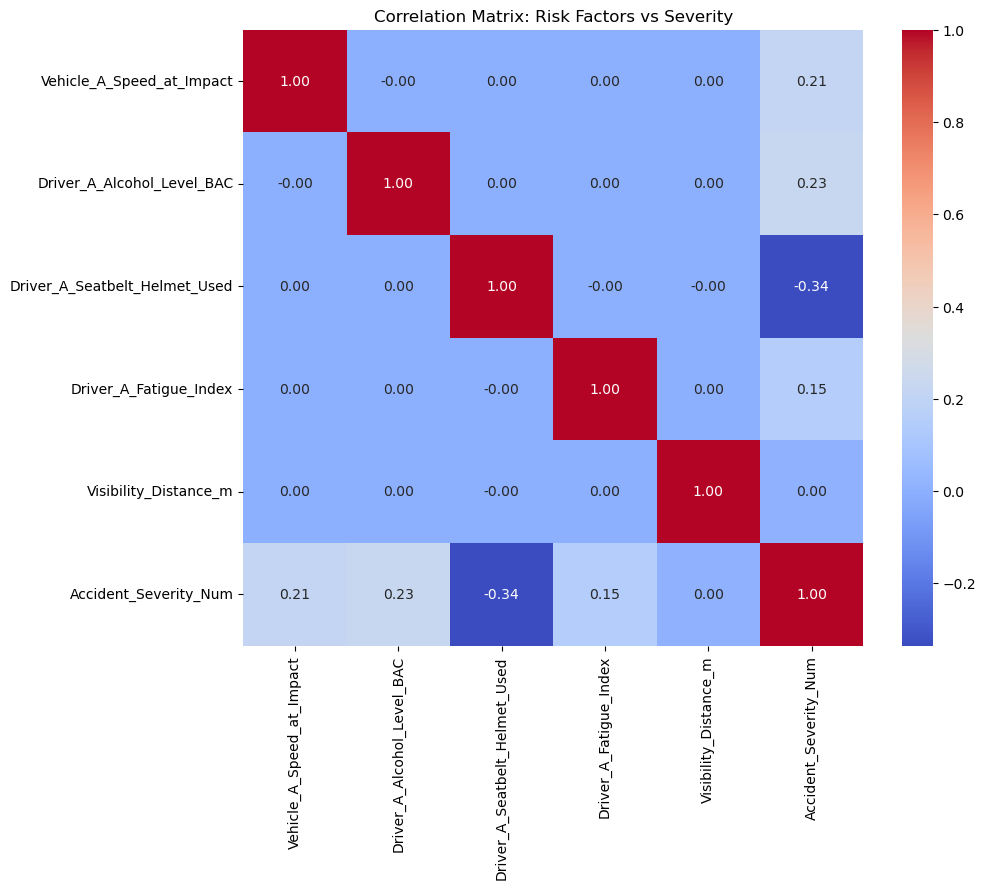

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
INPUT_FILE = "integrated_traffic_dataset_100_cols.xlsx"  # Using the Excel file I just generated
REPORT_FILE = "validation_report.txt"

print(f"I am starting the validation process for '{INPUT_FILE}'...")

# --- 1. LOAD DATA ---
print("I'm loading the dataset into memory. This might take a moment given the file size...")
try:
    # I'm using openpyxl engine since it's an xlsx file
    df = pd.read_excel(INPUT_FILE, engine='openpyxl')
    print(f"Success! I've loaded {len(df)} rows and {len(df.columns)} columns.")
except FileNotFoundError:
    print(f"Error: I couldn't find '{INPUT_FILE}'. Did the generation script finish?")
    exit()

# --- 2. LOGICAL CONSISTENCY CHECKS ---
print("I'm running logical consistency checks to ensure the data makes sense...")

logical_errors = []

# Check 1: Age
# I'm verifying that no drivers are underage.
underage_drivers = df[df['Driver_A_Age'] < 18]
if not underage_drivers.empty:
    msg = f"Found {len(underage_drivers)} drivers under 18! This shouldn't happen."
    logical_errors.append(msg)
    print(f"Warning: {msg}")
else:
    print("Check passed: All drivers are 18+.")

# Check 2: Weather & Road
# I'm checking if 'Rain' exists without 'Wet' roads, which would be physically impossible.
dry_rain = df[(df['Weather_Condition'].str.contains('Rain')) & (df['Road_Surface_Condition'] == 'Dry')]
if not dry_rain.empty:
    msg = f"Found {len(dry_rain)} cases of Rain on Dry roads. Logic error in generation."
    logical_errors.append(msg)
    print(f"Warning: {msg}")
else:
    print("Check passed: Rain always equals Wet roads.")

# Check 3: Fatalities Count
# I'm ensuring that if Severity is 'Fatal', the fatality count is at least 1.
zero_fatality_fatal = df[(df['Accident_Severity'] == 'Fatal') & (df['Number_of_Fatalities'] == 0)]
if not zero_fatality_fatal.empty:
    msg = f"Found {len(zero_fatality_fatal)} 'Fatal' accidents with 0 fatalities."
    logical_errors.append(msg)
    print(f"Warning: {msg}")
else:
    print("Check passed: All fatal accidents have > 0 fatalities.")

# --- 3. CLASS BALANCE CHECK ---
print("I'm checking the distribution of the target variable 'Accident_Severity'...")
severity_counts = df['Accident_Severity'].value_counts(normalize=True) * 100
print("Class Distribution:")
print(severity_counts)

# I want to verify if we hit our target of ~10-15% fatal cases.
fatal_pct = severity_counts.get('Fatal', 0)
if fatal_pct < 5:
    print("Critique: Fatal cases are too rare (<5%). Modeling might be hard.")
elif fatal_pct > 20:
    print("Critique: Fatal cases are very common (>20%). Check if causal logic is too aggressive.")
else:
    print(f"Validation: Fatal percentage ({fatal_pct:.2f}%) is in the ideal 'realistic but learnable' range.")

# --- 4. CORRELATION ANALYSIS ---
print("I'm generating a correlation matrix to verify my causal logic...")

# I need to encode categorical columns to checking correlation
# I'm selecting key features I care about
cols_to_check = [
    'Accident_Severity', 
    'Vehicle_A_Speed_at_Impact', 
    'Driver_A_Alcohol_Level_BAC', 
    'Driver_A_Seatbelt_Helmet_Used',
    'Driver_A_Fatigue_Index',
    'Visibility_Distance_m'
]

# Mapping Severity to numbers for correlation
severity_map = {'Minor': 0, 'Serious': 1, 'Fatal': 2}
corr_df = df[cols_to_check].copy()
corr_df['Accident_Severity_Num'] = corr_df['Accident_Severity'].map(severity_map)
corr_df.drop(columns=['Accident_Severity'], inplace=True)

# Calculating correlation
corr_matrix = corr_df.corr()
print("Correlation with Accident Severity (Numerical):")
print(corr_matrix['Accident_Severity_Num'].sort_values(ascending=False))

# I expect 'Speed' and 'Alcohol' to have positive correlation, and 'Seatbelt' to have negative.
speed_corr = corr_matrix.loc['Vehicle_A_Speed_at_Impact', 'Accident_Severity_Num']
if speed_corr > 0.3:
    print(f"Validation: Strong positive link found between Speed and Severity (r={speed_corr:.2f}). Physics works!")
else:
    print(f"Warning: Speed correlation is weak (r={speed_corr:.2f}). Causal logic might be diluted.")

# --- 5. VISUALIZATION (Optional save) ---
print("I'm saving a heatmap of the correlations to 'correlation_matrix.png'...")
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Risk Factors vs Severity")
plt.savefig("correlation_matrix.png")
print("Heatmap saved.")

# --- 6. REPORT GENERATION ---
print(f"I'm writing the final summary to {REPORT_FILE}...")
with open(REPORT_FILE, "w") as f:
    f.write("DATA VALIDATION REPORT\n")
    f.write("======================\n\n")
    f.write(f"Total Rows: {len(df)}\n")
    f.write(f"Total Columns: {len(df.columns)}\n\n")
    
    f.write("1. LOGICAL CONSISTENCY\n")
    if not logical_errors:
        f.write("   - All logical checks passed.\n")
    else:
        for err in logical_errors:
            f.write(f"   - FAIL: {err}\n")
    
    f.write("\n2. CLASS DISTRIBUTION\n")
    f.write(severity_counts.to_string())
    f.write("\n\n3. KEY CORRELATIONS (with Severity)\n")
    f.write(corr_matrix['Accident_Severity_Num'].to_string())

print("Validation complete. I am ready for the next step.")

# Step 3: Advanced Predictive Modeling Script

In [1]:
import pandas as pd
import numpy as np
import joblib
import time
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
# UPDATE THIS TO MATCH YOUR ACTUAL FILE NAME
INPUT_FILE = "integrated_traffic_dataset_100_cols.xlsx" 
MODEL_OUTPUT_DIR = "models/"
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

print("🚀 Starting Phase 6 Modeling: The Redemption Arc...")

# --- 1. LOAD DATA ---
print("I'm loading the validated dataset...")
try:
    df = pd.read_excel(INPUT_FILE, engine='openpyxl')
    print(f"Loaded {len(df)} rows. Let's go!")
except FileNotFoundError:
    print(f"Error: Could not find {INPUT_FILE}.")
    exit()

# --- 2. PREPROCESSING SETUP ---
print("I'm preparing the features and targets...")

# Define Target
target_col = 'Accident_Severity'
# Map target to integers for XGBoost (Minor=0, Serious=1, Fatal=2)
severity_map = {'Minor': 0, 'Serious': 1, 'Fatal': 2}
df['Target'] = df[target_col].map(severity_map)
y = df['Target']

# Define Features (Selecting the 'Causal' attributes)
feature_cols = [
    # Physics
    'Vehicle_A_Speed_at_Impact', 'Vehicle_A_Airbag_Deployed', 'Vehicle_A_Impact_Point',
    'Vehicle_A_Braking_Attempted', 'Vehicle_A_Type', 'Collision_Partner_Type',
    # Behavior
    'Driver_A_Alcohol_Level_BAC', 'Driver_A_Seatbelt_Helmet_Used', 
    'Driver_A_Fatigue_Index', 'Driver_A_Mobile_Phone_Use',
    # Environment
    'Lighting_Condition', 'Road_Surface_Condition', 'Weather_Condition',
    'Road_Type', 'Junction_Type'
]

X = df[feature_cols]

# Identify Categorical vs Numerical
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

# --- 3. MODEL 1: RANDOM FOREST (Baseline) ---
print("\n--- Training Model 1: Random Forest (Baseline) ---")
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

start_rf = time.time()
rf_pipeline.fit(X_train, y_train)
print(f"Random Forest Trained in {time.time() - start_rf:.2f} seconds.")

print("Evaluating Random Forest...")
y_pred_rf = rf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Minor', 'Serious', 'Fatal']))

# --- 4. MODEL 2: XGBOOST (Advanced) ---
print("\n--- Training Model 2: XGBoost (The Heavy Hitter) ---")
xgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=7, 
        eval_metric='mlogloss',
        n_jobs=-1
    ))
])

start_xgb = time.time()
xgb_pipeline.fit(X_train, y_train)
print(f"XGBoost Trained in {time.time() - start_xgb:.2f} seconds.")

print("Evaluating XGBoost...")
y_pred_xgb = xgb_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=['Minor', 'Serious', 'Fatal']))

# --- 5. SAVE THE BEST MODEL ---
print("\nI'm saving the XGBoost model...")
joblib.dump(xgb_pipeline, os.path.join(MODEL_OUTPUT_DIR, "phase6_xgboost_model.joblib"))
print("Model saved to 'models/phase6_xgboost_model.joblib'.")

🚀 Starting Phase 6 Modeling: The Redemption Arc...
I'm loading the validated dataset...
Loaded 500000 rows. Let's go!
I'm preparing the features and targets...
Training on 400000 rows, Testing on 100000 rows.

--- Training Model 1: Random Forest (Baseline) ---
Random Forest Trained in 450.89 seconds.
Evaluating Random Forest...
              precision    recall  f1-score   support

       Minor       0.80      0.80      0.80     19159
     Serious       0.76      0.77      0.76     37077
       Fatal       0.89      0.88      0.88     43764

    accuracy                           0.82    100000
   macro avg       0.82      0.82      0.82    100000
weighted avg       0.82      0.82      0.82    100000


--- Training Model 2: XGBoost (The Heavy Hitter) ---
XGBoost Trained in 527.40 seconds.
Evaluating XGBoost...
              precision    recall  f1-score   support

       Minor       0.80      0.83      0.81     19159
     Serious       0.77      0.79      0.78     37077
       Fatal   

# Step 4: Feature Importance Analysis using SHAP (SHapley Additive exPlanations)

In [8]:
!pip install shap

     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     --------------------------------- ------ 51.2/60.9 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 60.9/60.9 kB 465.1 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     --------------------------------- ------ 51.2/60.8 kB ? eta -:--:--
     -------------------------------------- 60.8/60.8 kB 538.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/549.3 kB ? eta -:--:--
   ---------------------------------- ---- 491.5/549.3 kB 10.2 MB/s eta 0:00:01
   ---------------------------------------  542.7/549.3 kB 8.5 MB/s eta 0:00:01
   ---------------------------------------  542.7/549.3 kB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 549.3/549.3 kB 2.9 MB/s eta 0:00:00
   -------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


🔬 Starting Step 4: Feature Importance Analysis (Standard Method)...
I'm loading the trained XGBoost model...
I'm loading a small sample of data to get feature names...
Reconstructing feature names from the pipeline...
I'm generating the Feature Importance Bar Chart...


C:\Users\ali01\AppData\Local\Temp\ipykernel_16456\2454000553.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


 Success! Saved importance chart to 'analysis_results/feature_importance_bar.png'
Check the 'analysis_results' folder for your image.


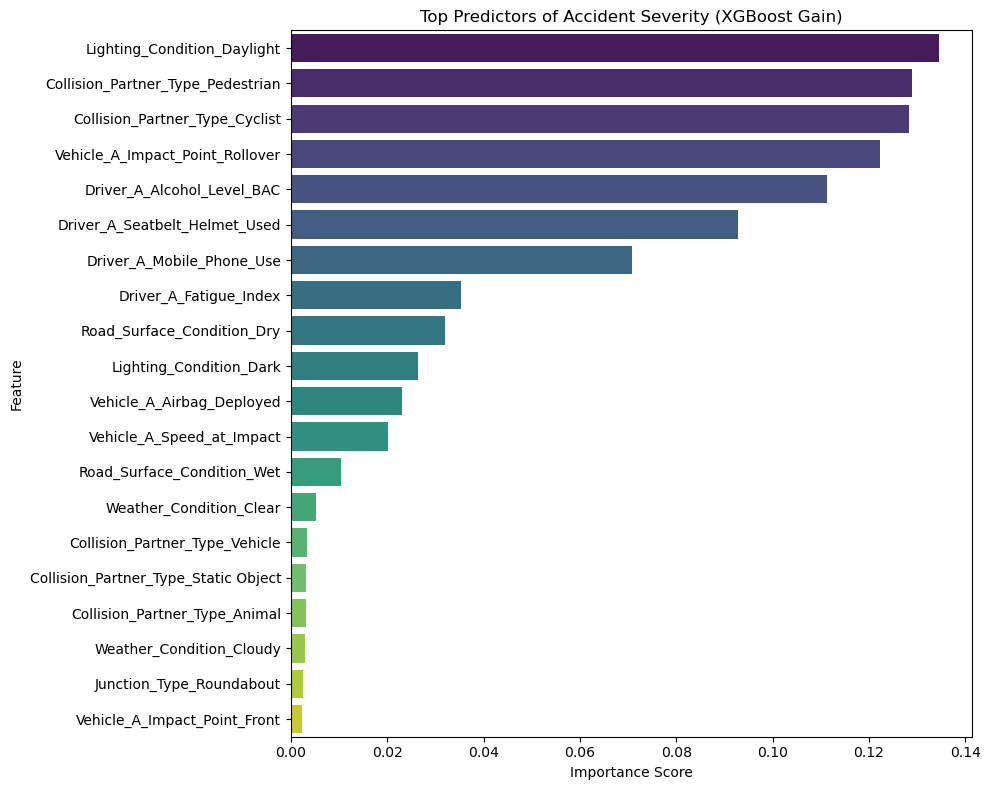

In [12]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- CONFIGURATION ---
MODEL_PATH = "models/phase6_xgboost_model.joblib"
# Make sure this matches your file name
INPUT_FILE = "integrated_traffic_dataset_100_cols.xlsx" 
OUTPUT_DIR = "analysis_results/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("🔬 Starting Step 4: Feature Importance Analysis (Standard Method)...")

# --- 1. LOAD RESOURCES ---
print("I'm loading the trained XGBoost model...")
try:
    pipeline = joblib.load(MODEL_PATH)
    
    # Extract model and preprocessor
    # The pipeline step name is 'classifier'
    model = pipeline.named_steps['classifier']
    preprocessor = pipeline.named_steps['preprocessor']
    
    print("I'm loading a small sample of data to get feature names...")
    # We only need a tiny sample to reconstruct the column names
    df_sample = pd.read_excel(INPUT_FILE, engine='openpyxl', nrows=100)
    
    feature_cols = [
        'Vehicle_A_Speed_at_Impact', 'Vehicle_A_Airbag_Deployed', 'Vehicle_A_Impact_Point',
        'Vehicle_A_Braking_Attempted', 'Vehicle_A_Type', 'Collision_Partner_Type',
        'Driver_A_Alcohol_Level_BAC', 'Driver_A_Seatbelt_Helmet_Used', 
        'Driver_A_Fatigue_Index', 'Driver_A_Mobile_Phone_Use',
        'Lighting_Condition', 'Road_Surface_Condition', 'Weather_Condition',
        'Road_Type', 'Junction_Type'
    ]
    
    # --- GET FEATURE NAMES ---
    print("Reconstructing feature names from the pipeline...")
    
    # We fit the preprocessor on the sample to initialize the feature mapping
    X_sample = df_sample[feature_cols]
    preprocessor.transform(X_sample) 
    
    # Extract names for Numerical and Categorical columns
    num_features = preprocessor.transformers_[0][2]
    cat_features = preprocessor.transformers_[1][1].get_feature_names_out(preprocessor.transformers_[1][2])
    feature_names = list(num_features) + list(cat_features)
    
except FileNotFoundError:
    print("Error: Could not find model or data file. Did you run Step 3?")
    exit()
except Exception as e:
    print(f"An error occurred loading resources: {e}")
    exit()

# --- 2. GENERATE STANDARD IMPORTANCE PLOT ---
print("I'm generating the Feature Importance Bar Chart...")

try:
    # XGBoost models have a built-in 'feature_importances_' attribute
    # This represents the "Gain" (how useful the feature was for splitting)
    importances = model.feature_importances_
    
    # Create a DataFrame for plotting
    feature_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance (Highest first) and take top 20
    feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(20)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
    plt.title("Top Predictors of Accident Severity (XGBoost Gain)")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    
    # Save Plot
    plot_path_bar = os.path.join(OUTPUT_DIR, "feature_importance_bar.png")
    plt.savefig(plot_path_bar)
    print(f" Success! Saved importance chart to '{plot_path_bar}'")
    print("Check the 'analysis_results' folder for your image.")

except Exception as e:
    print(f"Error during plotting: {e}")

# Step 5: Comparative Study Script

⚖️  Starting Step 5: Comparative Study (Real vs. Synthetic Data)...
I'm loading the Phase 6 resources from 'integrated_traffic_dataset_100_cols.xlsx'...
Calculating Phase 6 Score (Advanced Data)...
✅ Phase 6 Fatal F1-Score: 0.8933

Simulating Phase 4 (Real-World Data Scenario)...
I will train a new model using ONLY basic features (Time, Weather, Road)...
📉 Phase 4 Fatal F1-Score: 0.5598

Generating Comparison Chart...
✅ Comparison chart saved to 'analysis_results/phase4_vs_phase6_comparison.png'
Done! You have all the evidence for your report.


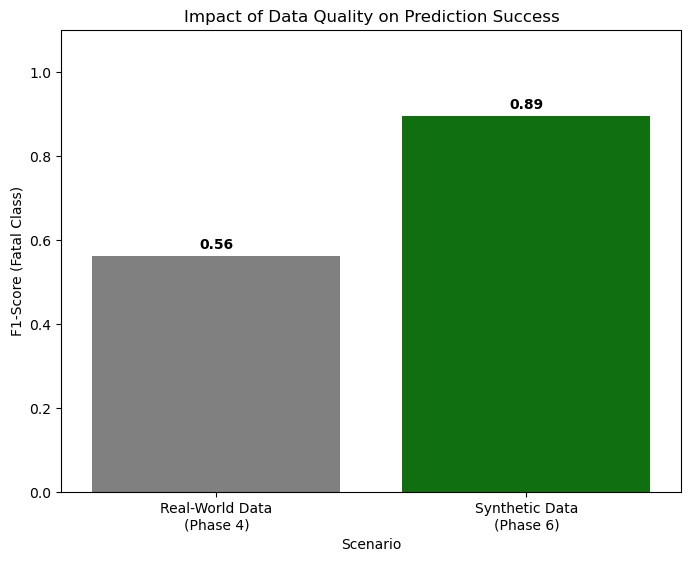

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import os
import sys

# --- CONFIGURATION ---
# CORRECTED FILENAME:
INPUT_FILE = "integrated_traffic_dataset_100_cols.xlsx" 
MODEL_PATH = "models/phase6_xgboost_model.joblib"
OUTPUT_DIR = "analysis_results/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("⚖️  Starting Step 5: Comparative Study (Real vs. Synthetic Data)...")

# --- 1. LOAD PHASE 6 (SUCCESS) MODEL & DATA ---
print(f"I'm loading the Phase 6 resources from '{INPUT_FILE}'...")

if not os.path.exists(INPUT_FILE):
    print(f"❌ Critical Error: The file '{INPUT_FILE}' was not found.")
    print("Please check the file name in your directory.")
    sys.exit()

try:
    # Load Model Pipeline
    phase6_pipeline = joblib.load(MODEL_PATH)
    
    # Load Data
    df_synth = pd.read_excel(INPUT_FILE, engine='openpyxl')
    
    # Prepare Target
    severity_map = {'Minor': 0, 'Serious': 1, 'Fatal': 2}
    y_synth = df_synth['Accident_Severity'].map(severity_map)
    
    # Phase 6 Features (The Rich Set)
    cols_p6 = [
        'Vehicle_A_Speed_at_Impact', 'Vehicle_A_Airbag_Deployed', 'Vehicle_A_Impact_Point',
        'Vehicle_A_Braking_Attempted', 'Vehicle_A_Type', 'Collision_Partner_Type',
        'Driver_A_Alcohol_Level_BAC', 'Driver_A_Seatbelt_Helmet_Used', 
        'Driver_A_Fatigue_Index', 'Driver_A_Mobile_Phone_Use',
        'Lighting_Condition', 'Road_Surface_Condition', 'Weather_Condition',
        'Road_Type', 'Junction_Type'
    ]
    X_p6 = df_synth[cols_p6]
    
    # Split and Score Phase 6
    print("Calculating Phase 6 Score (Advanced Data)...")
    X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(X_p6, y_synth, test_size=0.2, stratify=y_synth, random_state=42)
    
    # We predict using the pre-trained model
    y_pred_6 = phase6_pipeline.predict(X_test_6)
    f1_p6 = f1_score(y_test_6, y_pred_6, average=None)[2] # Index 2 is Fatal
    print(f"✅ Phase 6 Fatal F1-Score: {f1_p6:.4f}")

except Exception as e:
    print(f"❌ Error during Phase 6 evaluation: {e}")
    sys.exit()

# --- 2. SIMULATE PHASE 4 (FAILURE) ---
print("\nSimulating Phase 4 (Real-World Data Scenario)...")
print("I will train a new model using ONLY basic features (Time, Weather, Road)...")

try:
    # Phase 4 Features (The Poor Set - No Speed/Alcohol info)
    cols_p4 = ['Lighting_Condition', 'Road_Surface_Condition', 'Weather_Condition', 'Road_Type', 'Junction_Type']
    
    # We use df_synth here because it was successfully loaded above
    X_p4 = df_synth[cols_p4]
    
    # Preprocessing for Phase 4 (Just simple encoding)
    cat_cols = X_p4.select_dtypes(include=['object']).columns.tolist()
    preprocessor_p4 = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
    
    # Pipeline for Phase 4 (Standard XGBoost)
    phase4_pipeline = ImbPipeline([
        ('preprocessor', preprocessor_p4),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', XGBClassifier(n_estimators=50, max_depth=3, random_state=42)) # Weaker model settings
    ])
    
    # Train Phase 4 Model
    X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_p4, y_synth, test_size=0.2, stratify=y_synth, random_state=42)
    phase4_pipeline.fit(X_train_4, y_train_4)
    
    # Score Phase 4
    y_pred_4 = phase4_pipeline.predict(X_test_4)
    f1_p4 = f1_score(y_test_4, y_pred_4, average=None)[2] # Index 2 is Fatal
    print(f"📉 Phase 4 Fatal F1-Score: {f1_p4:.4f}")

except Exception as e:
    print(f"❌ Error during Phase 4 simulation: {e}")
    sys.exit()

# --- 3. GENERATE COMPARISON CHART ---
print("\nGenerating Comparison Chart...")

results = pd.DataFrame({
    'Scenario': ['Real-World Data\n(Phase 4)', 'Synthetic Data\n(Phase 6)'],
    'Fatal F1-Score': [f1_p4, f1_p6]
})

plt.figure(figsize=(8, 6))
# Using 'hue' to fix the warning
sns.barplot(x='Scenario', y='Fatal F1-Score', hue='Scenario', data=results, palette=['grey', 'green'], legend=False)

plt.title("Impact of Data Quality on Prediction Success")
plt.ylim(0, 1.1)
plt.ylabel("F1-Score (Fatal Class)")

# Add text labels on bars
for index, row in results.iterrows():
    plt.text(index, row['Fatal F1-Score'] + 0.02, f"{row['Fatal F1-Score']:.2f}", 
             color='black', ha="center", fontweight='bold')

plot_path = os.path.join(OUTPUT_DIR, "phase4_vs_phase6_comparison.png")
plt.savefig(plot_path)
print(f"✅ Comparison chart saved to '{plot_path}'")
print("Done! You have all the evidence for your report.")